# Security Anomaly Detection in Synthetic Enterprise Logs# Exploration Notebook

## 1. Introduction

This notebook presents the exploratory analysis, feature engineering validation, and statistical investigation of a synthetic enterprise security log dataset. The goal is to understand behavioral patterns, validate engineered features, and prepare the dataset for anomaly detection modeling.

## 2. Data Loading

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from visualization.visualize import plot_distribution, plot_anomalies
from statistical_analysis.stats_analysis import detect_anomalies_iqr
from feature_engineering.feature_engineering import add_moving_averages
from feature_engineering.feature_engineering import add_time_window_aggregation
from statistical_analysis.stats_analysis import run_seasonal_decomposition, plot_seasonal_decomposition


## 3. Dataset Inspection & Validation

### Objective
To validate the structure, realism, and analytical usefulness of the generated synthetic log dataset before proceeding to feature engineering and anomaly detection.

### Column by Column Inspection

The dataset contains the following fields:

In [24]:
print("Raw logs preview:")
display(raw_df.head())

Raw logs preview:


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 07:22:34,U002,donaldgarcia,HR,Staff,low,10.8.33.18,Berlin,Windows-Laptop,hr_portal,access,True,0,104,0,normal
1,2026-01-01 07:29:05,U007,lisa02,Finance,Analyst,medium,10.15.41.30,London,MacBook,security_dashboard,access,True,0,92,0,normal
2,2026-01-01 07:40:38,U007,lisa02,Finance,Analyst,medium,10.15.41.80,London,MacBook,finance_db,logout,True,0,50,0,normal
3,2026-01-01 07:54:26,U002,donaldgarcia,HR,Staff,low,10.8.33.111,Berlin,Windows-Laptop,security_dashboard,logout,True,0,37,0,normal
4,2026-01-01 08:07:53,U024,richard13,HR,Administrator,high,10.7.35.138,Toronto,MacBook,email_portal,logout,True,0,162,0,normal


In [28]:
raw_df = pd.read_csv("../data/raw/raw_logs.csv")
attack_df = pd.read_csv("../data/raw/logs_with_attacks.csv")
print("Raw dataset shape:", raw_df.shape)


Raw dataset shape: (5874, 16)



### Timestamp

- Timestamps are sequential and non-duplicated
- Events show realistic temporal progression
- No obvious inconsistencies or gaps

**Observation:**  
The dataset provides a strong temporal foundation for time-based analysis such as moving averages, aggregation, and anomaly detection.


### User Information

- Multiple users are present (e.g., `U002`, `donaldgarcia`)
- Departments (HR, IT, Finance) are well distributed
- Roles and privilege levels are logically assigned

**Observation:**  
The dataset supports behavioral profiling and role-based anomaly detection.

### Network & Device Context

- Source IP addresses vary across records
- Geographic locations are diverse
- Multiple device types are present

**Observation:**  
This variability enhances the ability to detect anomalies such as unusual login locations or suspicious device usage.

### Resource Access Patterns

- Systems accessed include:
  - `hr_portal`
  - `finance_db`
  - `admin_console`
  - `security_dashboard`
- Naming conventions reflect realistic enterprise environments

**Observation:**  
This enables modeling of:
- Privilege misuse
- Lateral movement across systems

### Action Types

- Actions include `login`, `access`, and `logout`
- Events are logically structured and consistent

**Observation:**  
The dataset accurately reflects real system activity logs, enabling meaningful sequence and behavioral analysis.


### Authentication Behavior

- `login_success` includes both True and False cases
- `failed_attempts` ranges between 0–2

**Observation:**  
This realistic distribution is critical for simulating:
- Credential stuffing
- Brute-force attacks
- Authentication anomalies

### Session Duration

- Values range from 0 to ~162 minutes
- Logical relationship observed:
  - Failed logins → short duration
  - Successful sessions → longer duration

**Observation:**  
Session modeling is highly realistic and suitable for anomaly detection based on session behavior.

### Ground Truth Labels

- `is_attack` is currently False for all records
- `attack_type` is empty

**Observation:**  
This represents a clean baseline dataset, suitable for controlled attack injection and evaluation.

## ⚠️ Minor Observations & Future Improvements

### Logout Event Duration

- Some logout events show relatively high session durations

**Interpretation:**  
This is not incorrect but can be refined for higher realism.

**Future Improvement:**
- Enforce shorter durations for logout-only events
- Separate session tracking from event logging if needed


## Overall Assessment

The dataset demonstrates:

- Strong structural integrity
- High realism across multiple dimensions
- Rich contextual features for behavioral analysis
- A solid baseline for anomaly detection experiments

## Conclusion

The generated dataset is well-suited for:
- Feature engineering
- Statistical analysis
- Temporal modeling
- Machine learning-based anomaly detection

No critical issues were identified, and the dataset is ready for the next stage of the pipeline.

## 4. Attack Distribution
This section checks how many records belong to each attack type.

In [29]:
print("Attack logs preview:")
display(attack_df.head())

Attack logs preview:


,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 00:48:34,U017,perezantonio,Engineering,Administrator,high,185.220.101.70,New York,Windows-Laptop,git_server,login,False,7,0,1,credential_stuffing
1,2026-01-01 01:18:13,U035,josephbrennan,IT,Administrator,high,185.220.101.79,Berlin,MacBook,finance_db,login,False,5,2,1,credential_stuffing
2,2026-01-01 02:10:38,U056,jenniferross,HR,Administrator,high,185.220.101.24,Toronto,MacBook,hr_portal,login,False,14,2,1,credential_stuffing
3,2026-01-01 02:14:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.30,Toronto,Windows-Laptop,admin_console,access,True,0,9,1,lateral_movement
4,2026-01-01 02:15:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.1.78,Toronto,Windows-Laptop,file_share,access,True,0,20,1,lateral_movement


In [30]:
print("Attack-injected dataset shape:", attack_df.shape)

Attack-injected dataset shape: (6244, 16)


In [4]:
attack_counts = attack_df["attack_type"].value_counts()
print(attack_counts)

attack_type
normal                 5874
credential_stuffing     120
lateral_movement        100
privilege_misuse         80
abnormal_session         70
Name: count, dtype: int64


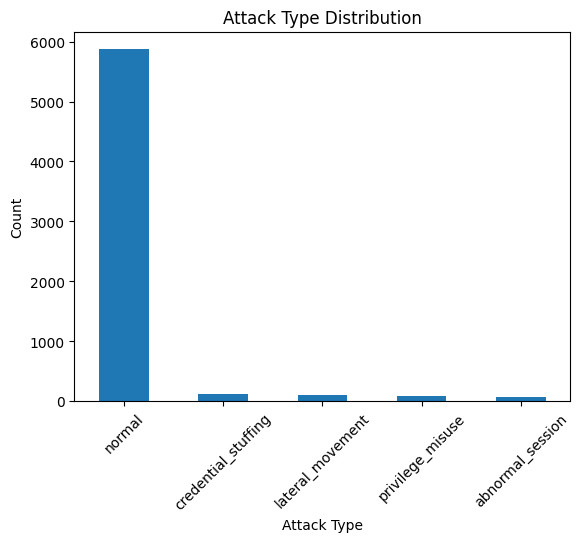

In [5]:
attack_counts.plot(kind="bar")
plt.title("Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Login Success vs Failure
This section checks the balance between successful and failed logins.

In [6]:
login_counts = attack_df["login_success"].value_counts()
print(login_counts)

login_success
True     5686
False     558
Name: count, dtype: int64


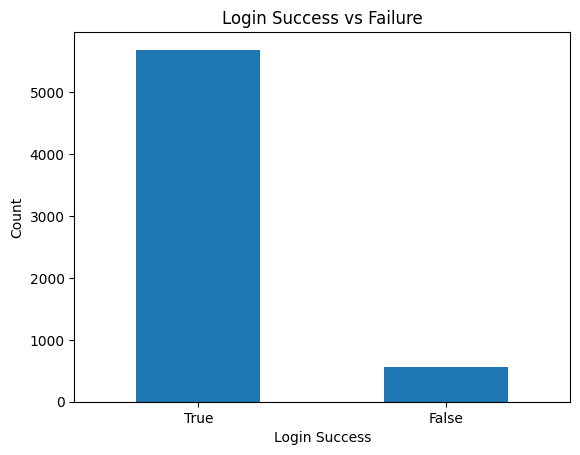

In [7]:
login_counts.plot(kind="bar")
plt.title("Login Success vs Failure")
plt.xlabel("Login Success")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Session Duration Distribution
This section checks how session durations are distributed and whether there are unusual extremes.

In [8]:
print(attack_df["session_duration_min"].describe())

count    6244.000000
mean       86.532671
std        62.183089
min         0.000000
25%        37.000000
50%        85.000000
75%       131.000000
max       716.000000
Name: session_duration_min, dtype: float64


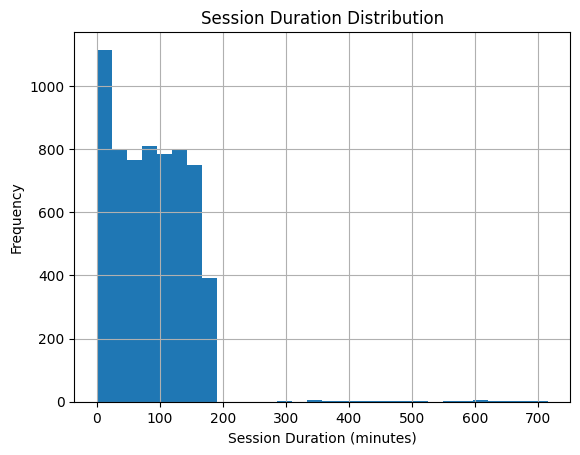

In [9]:
attack_df["session_duration_min"].hist(bins=30)
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Frequency")
plt.show()

## Attack Rows Only
This section inspects only records marked as attacks.

In [10]:
attack_only = attack_df[attack_df["is_attack"] == 1]
display(attack_only.head(10))

,timestamp,user_id,username,department,role,privilege_level,source_ip,location,device_type,resource_accessed,action,login_success,failed_attempts,session_duration_min,is_attack,attack_type
0,2026-01-01 00:48:34,U017,perezantonio,Engineering,Administrator,high,185.220.101.70,New York,Windows-Laptop,git_server,login,False,7,0,1,credential_stuffing
1,2026-01-01 01:18:13,U035,josephbrennan,IT,Administrator,high,185.220.101.79,Berlin,MacBook,finance_db,login,False,5,2,1,credential_stuffing
2,2026-01-01 02:10:38,U056,jenniferross,HR,Administrator,high,185.220.101.24,Toronto,MacBook,hr_portal,login,False,14,2,1,credential_stuffing
3,2026-01-01 02:14:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.30,Toronto,Windows-Laptop,admin_console,access,True,0,9,1,lateral_movement
4,2026-01-01 02:15:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.1.78,Toronto,Windows-Laptop,file_share,access,True,0,20,1,lateral_movement
5,2026-01-01 02:16:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.2.61,Toronto,Windows-Laptop,finance_db,access,True,0,22,1,lateral_movement
6,2026-01-01 02:17:41,U022,robinsonwilliam,Finance,Administrator,high,172.16.7.117,Toronto,Windows-Laptop,security_dashboard,access,True,0,16,1,lateral_movement
7,2026-01-01 02:27:10,U037,kayla51,Finance,Manager,low,185.220.101.43,Lagos,Linux-Workstation,finance_db,login,False,12,0,1,credential_stuffing
8,2026-01-01 02:37:35,U058,spenceamanda,IT,Staff,low,185.220.101.26,Berlin,Linux-Workstation,hr_portal,login,False,7,1,1,credential_stuffing
9,2026-01-01 03:08:55,U049,jeffrey28,IT,Manager,low,185.220.101.16,Lagos,Windows-Laptop,git_server,login,False,12,0,1,credential_stuffing


## User ID / Username Consistency Check
This section checks whether the same user_id is associated with multiple usernames.

In [11]:
user_username_check = attack_df.groupby("user_id")["username"].nunique()
mismatch_users = user_username_check[user_username_check > 1]

print("Number of user_id values linked to multiple usernames:", len(mismatch_users))
display(mismatch_users.head(10))

Number of user_id values linked to multiple usernames: 55


user_id
U001    6
U002    2
U003    3
U004    4
U005    5
U006    3
U007    4
U009    3
U011    4
U012    3
Name: username, dtype: int64

## Timestamp Inspection
This section checks whether attack events are clustering too heavily around certain hours.

In [12]:
attack_df["timestamp"] = pd.to_datetime(attack_df["timestamp"])
attack_df["hour"] = attack_df["timestamp"].dt.hour

hour_counts = attack_df["hour"].value_counts().sort_index()
print(hour_counts)

hour
0      26
1      36
2      48
3      40
4      14
7      98
8     228
9     441
10    647
11    684
12    652
13    630
14    654
15    632
16    568
17    408
18    258
19    103
20     18
21      1
22     20
23     38
Name: count, dtype: int64


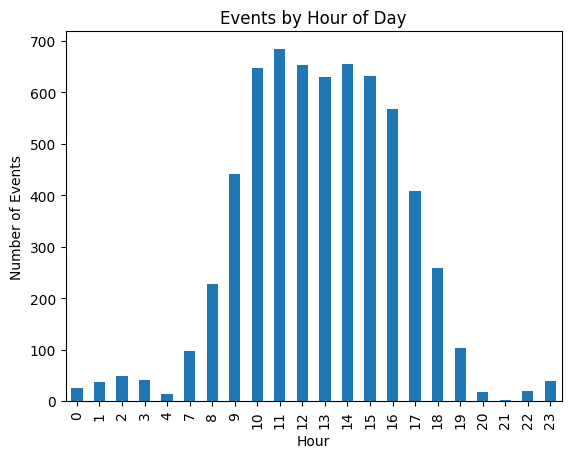

In [13]:
hour_counts.plot(kind="bar")
plt.title("Events by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.show()

## Observed Issues & Improvements

### Observed Issues

   - Possible mismatch between `user_id` and `username` in some injected attack rows.
   - Attack timestamps may cluster heavily in off-hours, which is useful for anomaly realism but may need smoothing.
   - Some attack scenarios may still look too isolated rather than fully sequence-based.

### Planned Improvements

- Ensure `username` always matches the selected `user_id` during attack injection.
- Add more realistic temporal sequences for attack scenarios.
- Improve internal vs external IP separation for attack events.
- Add user-level baseline features for later feature engineering.
- Review whether session durations for certain actions need tighter realism constraints.

## 5. Feature Engineering Validation

In [14]:
processed_df = pd.read_csv("../data/processed/processed_logs.csv")
processed_df.head()
processed_df.columns
processed_df[["risk_score", "session_zscore", "failed_zscore", "session_deviation"]].describe()
processed_df["is_attack"].value_counts()
processed_df.groupby("attack_type")["risk_score"].mean().sort_values(ascending=False)

attack_type
credential_stuffing    4.943433
abnormal_session       0.998463
normal                 0.506274
lateral_movement       0.491466
privilege_misuse       0.436204
Name: risk_score, dtype: float64

### Feature Engineering Observations
- The engineered risk score strongly highlights credential stuffing behavior, with a much higher average score than all other event categories.
- Abnormal session events also show elevated risk compared to normal activity.
- Lateral movement and privilege misuse are not yet well separated from normal behavior using the current risk formulation.
- This suggests that the present risk score is more sensitive to authentication related anomalies than access-pattern anomalies.
- Additional features may be required later to better capture resource traversal behavior and privilege violations.

## 6. Statistical Analysis Observations

### Objective
To examine the distribution of key features and identify potential outliers.

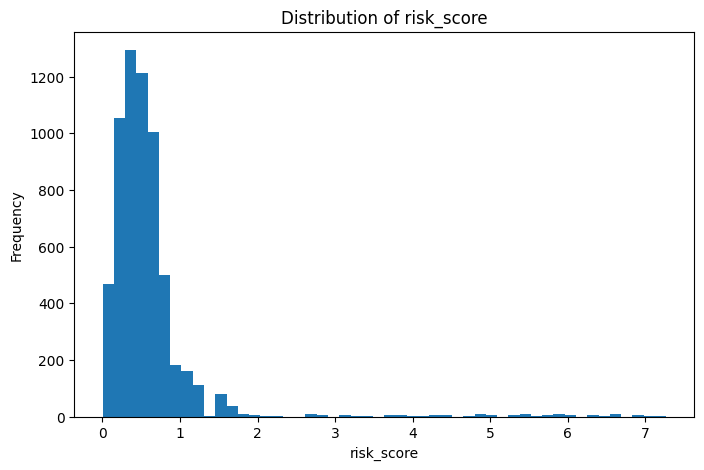

In [15]:
df = pd.read_csv("../data/processed/processed_logs_with_stats.csv")

plot_distribution(df, "risk_score", save=True)

## Observation:

- Distribution appears right skewed
- Majority of users have low to moderate risk scores
- Outliers exist at higher values → potential anomalies


## Risk Score Anomalies (IQR)

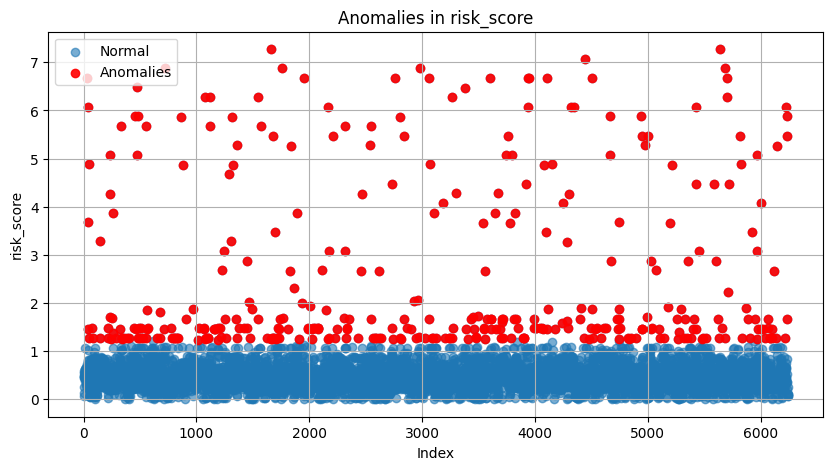

In [16]:
anomalies = detect_anomalies_iqr(df, "risk_score")
plot_anomalies(df, "risk_score", anomalies, save=True, filename="fig2_risk_score_anomalies.png")

## Observation:

- Clear separation between normal and anomalous points
- High-risk values correspond to injected attack scenarios
- IQR method captures extreme deviations effectively




## Session Duration Behavior

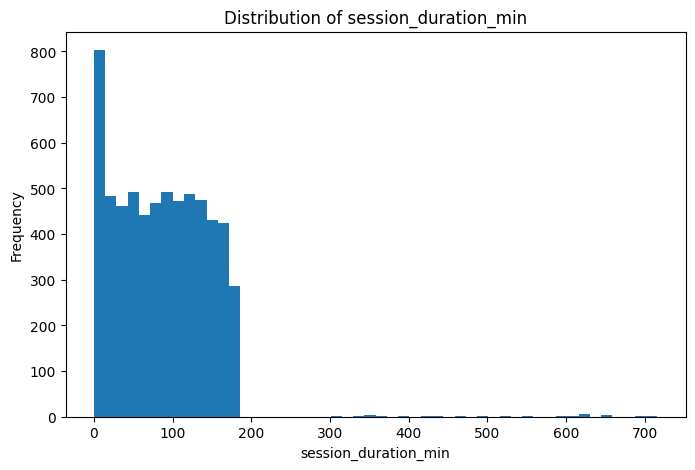

In [17]:
plot_distribution(df, "session_duration_min")

## Observation:

- Most sessions fall within normal working duration
- Long-duration sessions suggest persistence or misuse

## Login Frequency Patterns

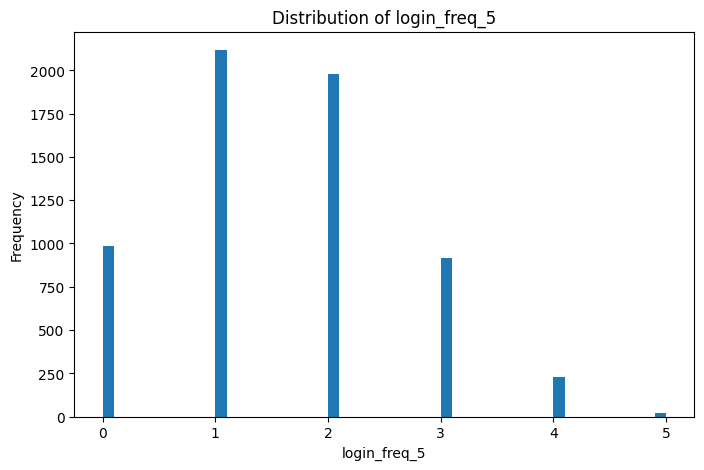

In [18]:
plot_distribution(df, "login_freq_5")

## Observation:

- Normal users show stable login frequency
- Sudden spikes indicate possible brute-force or automation	


## Moving Average Analysis (Temporal Smoothing)

### Objective
To analyze temporal patterns in the risk score by applying moving averages for smoothing short term fluctuations and highlighting sustained anomalous behavior.

### Methodology
- Applied rolling window smoothing (window = 5)
- Computed moving average of:
  - Risk score
  - Login frequency
- Derived deviation feature:
  - Difference between actual risk score and its moving average
- Sorted data chronologically to preserve temporal consistency

In [19]:
df = add_moving_averages(df, window=5)
df[['risk_score', 'risk_score_ma_5', 'risk_score_dev_5']].head(10)

,risk_score,risk_score_ma_5,risk_score_dev_5
0,0.133372,0.133372,0.000000
1,0.265240,0.199306,0.065934
2,0.072262,0.156958,-0.084696
3,0.487755,0.239657,0.248097
4,0.449958,0.281717,0.168241
5,0.597698,0.374583,0.223115
6,0.465829,0.414700,0.051129
7,0.536588,0.507566,0.029023
8,0.475478,0.505110,-0.029632
9,0.385043,0.492127,-0.107084


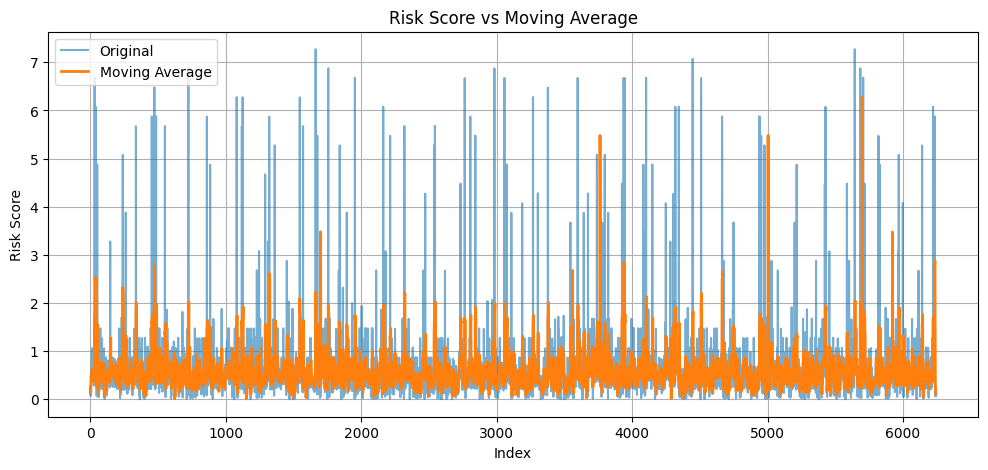

In [20]:

plt.figure(figsize=(12, 5))
plt.plot(df['risk_score'], label='Original', alpha=0.6)
plt.plot(df['risk_score_ma_5'], label='Moving Average', linewidth=2)

plt.title("Risk Score vs Moving Average")
plt.xlabel("Index")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True)

plt.show()

### Observations

- The moving average smooths short-term fluctuations, revealing the underlying trend in user behavior.
- Normal user activity appears stable with low variance over time.
- Sharp spikes in the original risk score indicate potential anomalous events such as:
  - Credential stuffing
  - Automated login attempts
- The deviation between actual and smoothed values highlights sudden behavioral changes more clearly.

### Insight

Moving averages improve anomaly detection by:
- Reducing noise in the signal
- Making abnormal spikes more distinguishable
- Providing a temporal baseline for comparison

This is particularly useful for detecting **burst-based attacks** and **short lived anomalies**.

### Limitation

- Moving averages may delay detection of very sudden attacks due to smoothing effect.
- Not sufficient alone for detecting complex attack patterns like lateral movement.

### Next Step

Incorporate time-window aggregation and seasonal decomposition for deeper temporal analysis.

## Time-Window Aggregation

### Objective
To aggregate user activity into fixed temporal windows in order to capture short-duration attack bursts and summarize behavioral intensity over time.

### Method
User events were grouped by `user_id` and resampled into 5-minute windows. For each window, the following metrics were computed:
- Total login count
- Total failed login attempts
- Mean risk score

This transformation converts event-level logs into structured time series data suitable for temporal analysis.

### Implementation

In [21]:
df_agg = add_time_window_aggregation(df, window='5min').fillna(0)
df_agg.head()


,user_id,timestamp,login_count_5min,failed_attempts_5min,risk_score_mean_5min
0,U001,2026-01-01 09:05:00,0.0,0,0.133372
1,U001,2026-01-01 09:10:00,0.0,0,0.000000
2,U001,2026-01-01 09:15:00,0.0,0,0.000000
3,U001,2026-01-01 09:20:00,0.0,0,0.000000
4,U001,2026-01-01 09:25:00,0.0,0,0.000000


### Output Preview
The resulting dataset represents user activity aggregated into fixed 5-minute intervals, enabling clearer temporal pattern analysis.

### Observations
- Event-level logs are successfully transformed into a time-windowed representation of user activity.
- Periods of inactivity are explicitly represented, making temporal gaps and burst behavior more visible.
- Repeated events within short intervals are consolidated, allowing detection of high intensity activity bursts.
- The mean risk score provides a smoother and more interpretable signal compared to raw event-level fluctuations.

### Interpretation
Time-window aggregation enhances anomaly detection by highlighting concentrated activity patterns that may indicate automated attacks or credential stuffing. By summarizing behavior over time, it becomes easier to detect short lived anomalies that would otherwise be obscured in raw logs.

### Analytical Value
This step provides a strong temporal foundation for subsequent analysis and modeling by:
- Reducing noise from individual events
- Emphasizing behavioral trends over time
- Enabling integration with time-based anomaly detection techniques

### Limitations
- Aggregation may obscure fine grained event ordering within each time window.
- Windows with no activity may require handling (e.g., filling missing values) depending on downstream modeling needs.

### Next Step
Incorporate seasonal decomposition and temporal anomaly detection techniques to further analyze periodic patterns and improve detection of subtle behavioral anomalies.

## Seasonal Decomposition

### Objective
To separate temporal behavior into trend, seasonal, and residual components in order to better understand recurring patterns and irregular deviations in engineered features.

### Method
Seasonal decomposition was applied to the time indexed feature series after sorting by timestamp and resampling into uniform 5-minute intervals. The method separates each signal into:
- Trend component
- Seasonal component
- Residual component

This helps distinguish systematic temporal structure from abnormal fluctuations.

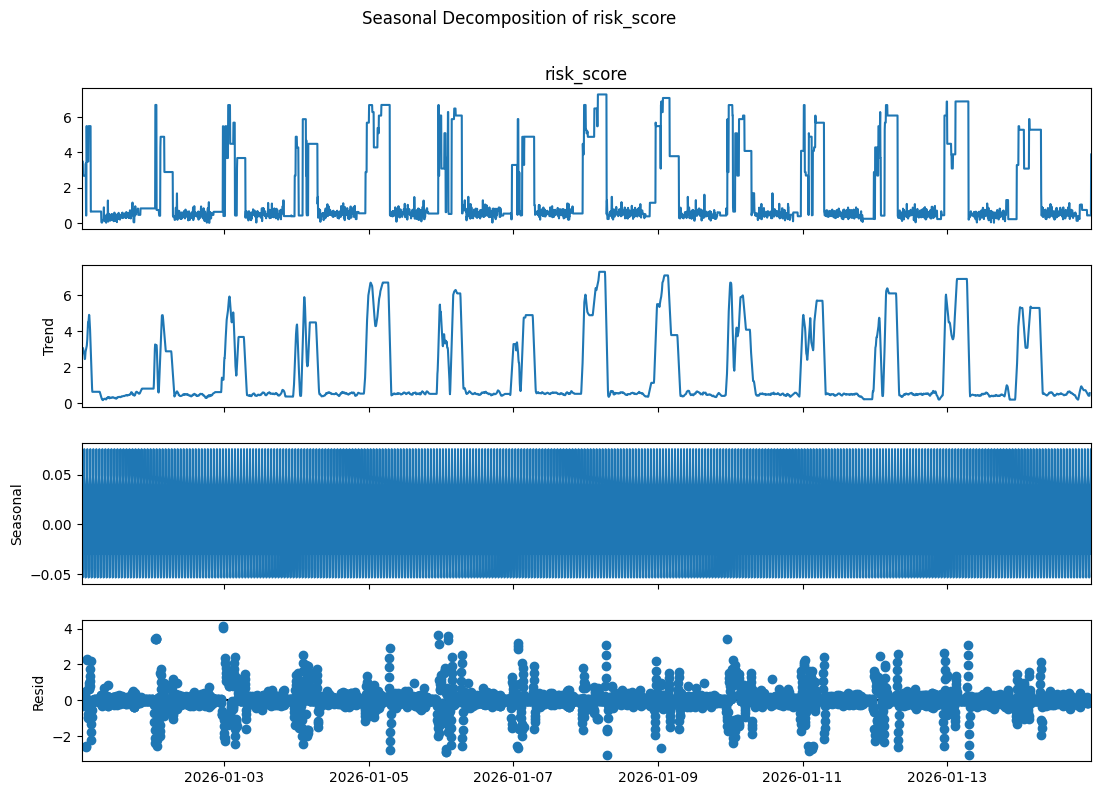

In [22]:
decomp = run_seasonal_decomposition(df, column="risk_score", period=12, model="additive")
plot_seasonal_decomposition(decomp, "risk_score")

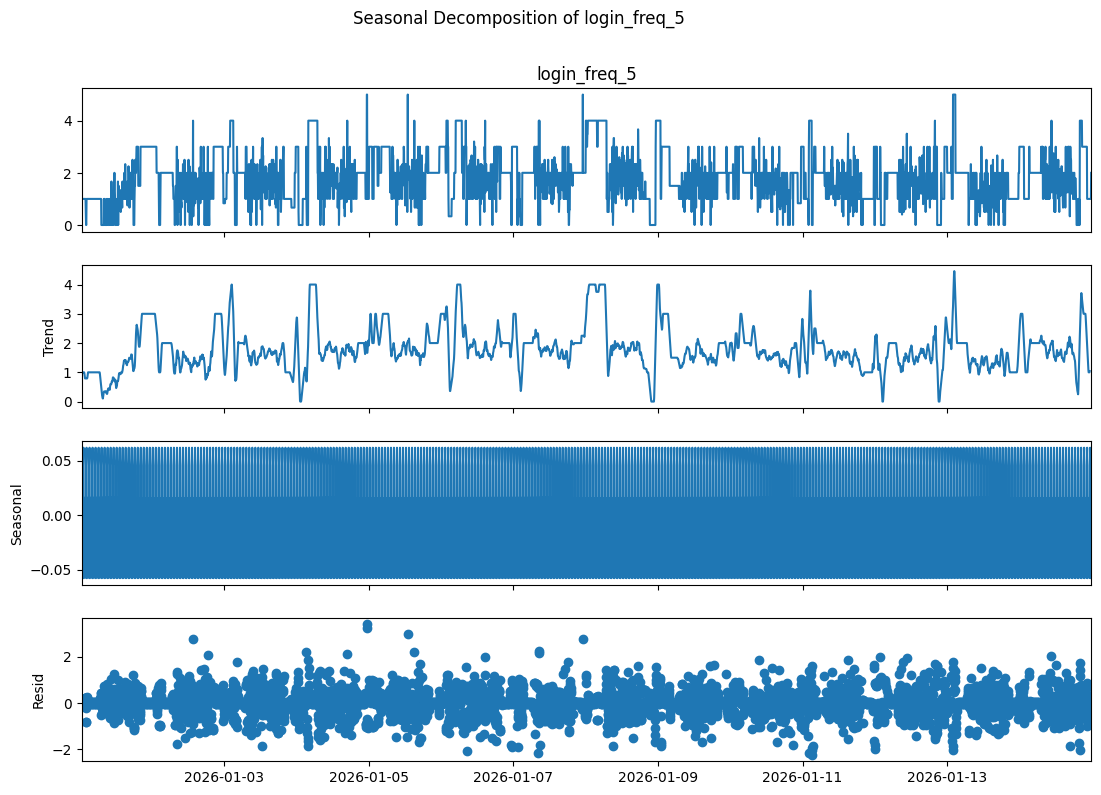

In [23]:
decomp_login = run_seasonal_decomposition(df, column="login_freq_5", period=12, model="additive")
plot_seasonal_decomposition(decomp_login, "login_freq_5")

### Observations

#### Login Frequency (`login_freq_5`)
- The original series shows irregular fluctuations with no strong long term upward or downward trend.
- The trend component remains relatively stable, indicating consistent user login behavior over time.
- The seasonal component is very weak and nearly flat, suggesting **no meaningful periodic pattern** in login frequency.
- The residual component captures most of the variability, indicating that fluctuations are largely random rather than cyclic.

#### Interpretation
Login behavior does not exhibit strong periodicity, implying that anomalies in login frequency are more likely due to irregular events (e.g., bursts or attacks) rather than predictable temporal patterns.

#### Risk Score (`risk_score`)
- The original signal shows **distinct sharp spikes**, representing high-risk events.
- The trend component clearly captures repeated increases in risk levels over time, suggesting structured bursts of suspicious activity.
- The seasonal component remains minimal, indicating **lack of consistent periodic behavior** in risk scores.
- The residual component contains scattered deviations, representing irregular anomalies not explained by trend or seasonality.

#### Interpretation
Risk score behavior is dominated by **episodic spikes rather than cyclical patterns**, which aligns with simulated attack scenarios such as credential stuffing or brute-force bursts.

### Key Insights
- Both features show **weak or negligible seasonality**, confirming that anomalies are not driven by periodic user behavior.
- The **trend component in risk_score** effectively captures attack bursts, making it a valuable signal for anomaly detection.
- The **residual component highlights unpredictable deviations**, which are strong candidates for anomaly detection.

### Analytical Value
Seasonal decomposition confirms that:
- The dataset is **event-driven rather than seasonally driven**
- Anomalies are better captured through:
  - spike detection
  - deviation from trend
  - statistical outlier methods

### Conclusion
Seasonal decomposition provides limited value for periodic pattern detection in this dataset, but it is highly useful for:
- isolating burst-based attack behavior (trend)
- identifying unexplained anomalies (residuals)

This reinforces the need to focus on **statistical and machine learning-based anomaly detection methods** rather than purely seasonal modeling.

## 7. Summary of Findings

- The dataset exhibits strong behavioral variability with realistic enterprise patterns.
- Feature engineering successfully captures temporal and behavioral anomalies.
- Statistical analysis reveals clear deviations in risk-related features.
- Temporal analysis confirms that anomalies are burst-driven rather than seasonal.

## 8. Next Steps

- Apply unsupervised machine learning models:
  - Isolation Forest
  - Local Outlier Factor (LOF)
  - One-Class SVM
  - Autoencoder

- Evaluate detection performance using synthetic ground truth

- Visualize anomalies using dimensionality reduction (t-SNE / UMAP)